# Task 3 — CycleGAN Photo <-> Monet Style Transfer
**Author:** Ritika Mukesh Neema

Real source from `src/*.py` (ResNet generators, PatchGAN discriminators, LSGAN + cycle-consistency + identity loss, image replay buffer), followed by the real captured console output and metrics from the completed 80-epoch run on an RTX 5090 (see `results.md`, `outputs/console_train.log`, `outputs/full_metrics_report.csv`).

## Dataset

In [1]:
"""
Task 3.1(1) - Unpaired image domains.

Loads domain A (e.g. monet_jpg/) and domain B (e.g. photo_jpg/) as two
independent, unpaired image lists -- exactly what CycleGAN needs. Domain B
is sampled with a random offset each __getitem__ so pairs are never aligned
(this is what makes it "unpaired" translation, not paired pix2pix).
"""
import os
import random

from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as T

IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")


def list_images(folder):
    return sorted(
        os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(IMG_EXTENSIONS)
    )


def make_transform(img_size, train=True):
    ops = [T.Resize((img_size, img_size), Image.BICUBIC)]
    if train:
        ops.append(T.RandomHorizontalFlip())
    ops += [T.ToTensor(), T.Normalize([0.5] * 3, [0.5] * 3)]  # -> [-1, 1]
    return T.Compose(ops)


class UnpairedImageDataset(Dataset):
    def __init__(self, dir_a, dir_b, img_size=256, train=True):
        self.files_a = list_images(dir_a)
        self.files_b = list_images(dir_b)
        if len(self.files_a) == 0 or len(self.files_b) == 0:
            raise ValueError(
                f"Found {len(self.files_a)} images in {dir_a} and {len(self.files_b)} in {dir_b} "
                "-- both domains need at least one image."
            )
        self.transform = make_transform(img_size, train)
        self.train = train

    def __len__(self):
        # Epoch length = the SMALLER domain (typically monet_jpg, ~300 images,
        # vs. photo_jpg, ~7000). Using max() here (as some CycleGAN reference
        # implementations do) would make every epoch ~7000 steps, which is
        # impractical on a time-boxed GPU Lab slot. With min(), one epoch = one
        # full pass over the smaller/rarer domain, and photos are still seen
        # via random sampling (see __getitem__) -- just spread across more
        # epochs rather than crammed into one. Total photo coverage over a
        # full training run is unaffected; only wall-clock-per-epoch changes.
        return min(len(self.files_a), len(self.files_b))

    def __getitem__(self, idx):
        path_a = self.files_a[idx % len(self.files_a)]
        # unpaired: random index into B so A/B are never the "same" content
        b_idx = random.randint(0, len(self.files_b) - 1) if self.train else idx % len(self.files_b)
        path_b = self.files_b[b_idx]
        img_a = self.transform(Image.open(path_a).convert("RGB"))
        img_b = self.transform(Image.open(path_b).convert("RGB"))
        return {"A": img_a, "B": img_b, "path_A": path_a, "path_B": path_b}


class SingleDomainDataset(Dataset):
    """Used at inference time to translate every image in one domain, in order."""

    def __init__(self, folder, img_size=256):
        self.files = list_images(folder)
        if len(self.files) == 0:
            raise ValueError(f"No images found in {folder}")
        self.transform = make_transform(img_size, train=False)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        img = self.transform(Image.open(path).convert("RGB"))
        return {"image": img, "path": path, "filename": os.path.basename(path)}


## Utilities (image buffer, checkpointing, etc.)

In [1]:
"""Shared training utilities: image replay buffer, LR schedule, denorm helper."""
import random
import torch


class ImagePool:
    """
    Replay buffer of previously generated fakes (Shrivastava et al. 2017 / the
    CycleGAN paper section 4): stabilizes discriminator training by showing it
    a history of generated images instead of only the very latest batch.
    """

    def __init__(self, pool_size=50):
        self.pool_size = pool_size
        self.images = []

    def query(self, images):
        if self.pool_size == 0:
            return images
        out = []
        for img in images:
            img = img.unsqueeze(0)
            if len(self.images) < self.pool_size:
                self.images.append(img)
                out.append(img)
            elif random.random() > 0.5:
                idx = random.randint(0, self.pool_size - 1)
                out.append(self.images[idx].clone())
                self.images[idx] = img
            else:
                out.append(img)
        return torch.cat(out, dim=0)


def lambda_lr(epoch, n_epochs, n_epochs_decay):
    """1.0 for the first n_epochs, then linearly decays to 0 over n_epochs_decay."""
    if epoch < n_epochs:
        return 1.0
    return max(0.0, 1.0 - (epoch - n_epochs) / float(n_epochs_decay))


def denorm(x):
    """[-1, 1] -> [0, 1] for saving/viewing images."""
    return (x * 0.5 + 0.5).clamp(0, 1)


## Models — ResNet generators + PatchGAN discriminators

In [1]:
"""
Task 3.1(2) - CycleGAN architecture: two generators (G_A2B, G_B2A) and two
discriminators (D_A, D_B). Standard Zhu et al. (2017) design: ResNet-based
generator with instance normalization, 70x70 PatchGAN discriminator.
Implemented from scratch with plain nn.Conv2d/nn.ConvTranspose2d/nn.InstanceNorm2d
building blocks -- no pretrained backbones anywhere in G/D.
"""
import torch
import torch.nn as nn


class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, kernel_size=3),
            nn.InstanceNorm2d(dim),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, kernel_size=3),
            nn.InstanceNorm2d(dim),
        )

    def forward(self, x):
        return x + self.block(x)


class ResnetGenerator(nn.Module):
    """c7s1-64, d128, d256, R256*n_blocks, u128, u64, c7s1-3 (Zhu et al. naming)."""

    def __init__(self, in_ch=3, out_ch=3, ngf=64, n_blocks=9):
        super().__init__()
        model = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_ch, ngf, kernel_size=7),
            nn.InstanceNorm2d(ngf),
            nn.ReLU(inplace=True),
        ]
        # downsampling
        ch = ngf
        for _ in range(2):
            model += [
                nn.Conv2d(ch, ch * 2, kernel_size=3, stride=2, padding=1),
                nn.InstanceNorm2d(ch * 2),
                nn.ReLU(inplace=True),
            ]
            ch *= 2
        # residual blocks
        for _ in range(n_blocks):
            model += [ResidualBlock(ch)]
        # upsampling
        for _ in range(2):
            model += [
                nn.ConvTranspose2d(ch, ch // 2, kernel_size=3, stride=2, padding=1, output_padding=1),
                nn.InstanceNorm2d(ch // 2),
                nn.ReLU(inplace=True),
            ]
            ch //= 2
        model += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(ch, out_ch, kernel_size=7),
            nn.Tanh(),
        ]
        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)


class PatchGANDiscriminator(nn.Module):
    """70x70 PatchGAN: C64-C128-C256-C512, no norm on first layer."""

    def __init__(self, in_ch=3, ndf=64):
        super().__init__()

        def block(cin, cout, stride=2, norm=True):
            layers = [nn.Conv2d(cin, cout, kernel_size=4, stride=stride, padding=1)]
            if norm:
                layers.append(nn.InstanceNorm2d(cout))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        layers = []
        layers += block(in_ch, ndf, norm=False)
        layers += block(ndf, ndf * 2)
        layers += block(ndf * 2, ndf * 4)
        layers += block(ndf * 4, ndf * 8, stride=1)
        layers += [nn.Conv2d(ndf * 8, 1, kernel_size=4, stride=1, padding=1)]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)  # (B, 1, H', W') patch logits


def init_weights(net, gain=0.02):
    def _init(m):
        classname = m.__class__.__name__
        if hasattr(m, "weight") and ("Conv" in classname or "Linear" in classname):
            nn.init.normal_(m.weight.data, 0.0, gain)
            if hasattr(m, "bias") and m.bias is not None:
                nn.init.constant_(m.bias.data, 0.0)
        elif "InstanceNorm2d" in classname and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, gain)
            nn.init.constant_(m.bias.data, 0.0)

    net.apply(_init)
    return net


def num_params(model):
    return sum(p.numel() for p in model.parameters())


## Training loop (LSGAN + cycle-consistency + identity loss)

In [1]:
"""
Task 3.1(2,3,5) - CycleGAN training: adversarial (LSGAN) + cycle-consistency
+ identity loss, image pool for discriminator stability, linear LR decay.
Logs everything needed for Task 3's "analyse training behaviour" requirement:
raw per-step JSONL log (do not hand-edit -- evidence trail), gen/disc loss
curves, cycle/identity loss curves, gradient norms + NaN/Inf count, images/sec,
peak memory, total training time, parameter counts.
"""
import argparse
import json
import os
import time

try:
    import resource
    HAS_RESOURCE = True
except ImportError:
    HAS_RESOURCE = False

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from models import ResnetGenerator, PatchGANDiscriminator, init_weights, num_params
from dataset import UnpairedImageDataset
from utils import ImagePool, lambda_lr


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data_dir_a", default="../../data/monet_jpg", help="domain A (e.g. Monet paintings)")
    ap.add_argument("--data_dir_b", default="../../data/photo_jpg", help="domain B (e.g. photos)")
    ap.add_argument("--out_dir", default="../outputs")
    ap.add_argument("--ckpt_dir", default="../checkpoints")
    ap.add_argument("--img_size", type=int, default=256)
    ap.add_argument("--batch_size", type=int, default=1)
    ap.add_argument("--n_epochs", type=int, default=10, help="epochs at full LR")
    ap.add_argument("--n_epochs_decay", type=int, default=10, help="epochs of linear LR decay to 0")
    ap.add_argument("--lr", type=float, default=2e-4)
    ap.add_argument("--beta1", type=float, default=0.5)
    ap.add_argument("--lambda_cycle", type=float, default=10.0)
    ap.add_argument("--lambda_identity", type=float, default=5.0)
    ap.add_argument("--n_blocks", type=int, default=9, help="generator residual blocks (6 for 128px, 9 for 256px)")
    ap.add_argument("--pool_size", type=int, default=50)
    ap.add_argument("--seed", type=int, default=42)
    ap.add_argument("--log_every", type=int, default=20)
    ap.add_argument("--save_every_epoch", type=int, default=1)
    ap.add_argument("--max_steps", type=int, default=None, help="optional hard cap for smoke tests")
    args = ap.parse_args()

    torch.manual_seed(args.seed)
    os.makedirs(args.out_dir, exist_ok=True)
    os.makedirs(args.ckpt_dir, exist_ok=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    dataset = UnpairedImageDataset(args.data_dir_a, args.data_dir_b, args.img_size, train=True)
    loader = DataLoader(dataset, batch_size=args.batch_size, shuffle=True, num_workers=2, drop_last=True)
    print(f"Domain A (monet-style): {len(dataset.files_a)} images | Domain B (photo-style): {len(dataset.files_b)} images")

    G_A2B = init_weights(ResnetGenerator(n_blocks=args.n_blocks)).to(device)  # photo -> monet
    G_B2A = init_weights(ResnetGenerator(n_blocks=args.n_blocks)).to(device)  # monet -> photo
    D_A = init_weights(PatchGANDiscriminator()).to(device)  # real vs fake monet
    D_B = init_weights(PatchGANDiscriminator()).to(device)  # real vs fake photo

    total_params = sum(num_params(m) for m in [G_A2B, G_B2A, D_A, D_B])
    print(f"Total parameters (G_A2B+G_B2A+D_A+D_B): {total_params:,}")

    criterion_gan = nn.MSELoss()   # LSGAN
    criterion_cycle = nn.L1Loss()
    criterion_identity = nn.L1Loss()

    opt_G = torch.optim.Adam(
        list(G_A2B.parameters()) + list(G_B2A.parameters()), lr=args.lr, betas=(args.beta1, 0.999)
    )
    opt_D = torch.optim.Adam(
        list(D_A.parameters()) + list(D_B.parameters()), lr=args.lr, betas=(args.beta1, 0.999)
    )

    total_epochs = args.n_epochs + args.n_epochs_decay
    sched_G = torch.optim.lr_scheduler.LambdaLR(
        opt_G, lr_lambda=lambda e: lambda_lr(e, args.n_epochs, args.n_epochs_decay)
    )
    sched_D = torch.optim.lr_scheduler.LambdaLR(
        opt_D, lr_lambda=lambda e: lambda_lr(e, args.n_epochs, args.n_epochs_decay)
    )

    pool_fake_A = ImagePool(args.pool_size)  # fake "monet" (domain A style)
    pool_fake_B = ImagePool(args.pool_size)  # fake "photo" (domain B style)

    log_path = os.path.join(args.out_dir, "train_log.jsonl")
    log_f = open(log_path, "w")  # raw, unedited log -- evidence trail

    history = {"loss_G": [], "loss_D": [], "loss_cycle": [], "loss_identity": [], "loss_gan": []}
    grad_norms, nan_events = [], 0
    n_images_seen = 0
    t_start = time.time()
    step = 0

    for epoch in range(total_epochs):
        epoch_losses = {k: 0.0 for k in history}
        n_batches = 0
        t_epoch = time.time()

        for batch in loader:
            if args.max_steps and step >= args.max_steps:
                break
            real_A = batch["A"].to(device)  # monet-style
            real_B = batch["B"].to(device)  # photo-style
            b = real_A.size(0)

            # ---------------- Generators ----------------
            opt_G.zero_grad(set_to_none=True)

            # identity loss: G_A2B(real_A) should look like real_A already (color preservation)
            idt_A = G_B2A(real_A)
            loss_idt_A = criterion_identity(idt_A, real_A) * args.lambda_cycle * args.lambda_identity / 10.0
            idt_B = G_A2B(real_B)
            loss_idt_B = criterion_identity(idt_B, real_B) * args.lambda_cycle * args.lambda_identity / 10.0

            fake_B = G_A2B(real_A)  # translate a domain-A (monet) image into domain-B (photo) style
            fake_A = G_B2A(real_B)  # translate a domain-B (photo) image into domain-A (monet) style
                                     # -- this is the direction the Kaggle submission needs

            pred_fake_A = D_A(fake_A)
            loss_gan_B2A = criterion_gan(pred_fake_A, torch.ones_like(pred_fake_A))
            pred_fake_B = D_B(fake_B)
            loss_gan_A2B = criterion_gan(pred_fake_B, torch.ones_like(pred_fake_B))

            rec_A = G_B2A(fake_B)
            loss_cycle_A = criterion_cycle(rec_A, real_A) * args.lambda_cycle
            rec_B = G_A2B(fake_A)
            loss_cycle_B = criterion_cycle(rec_B, real_B) * args.lambda_cycle

            loss_G = (loss_gan_A2B + loss_gan_B2A + loss_cycle_A + loss_cycle_B + loss_idt_A + loss_idt_B)
            loss_G.backward()
            grad_norm_G = torch.nn.utils.clip_grad_norm_(
                list(G_A2B.parameters()) + list(G_B2A.parameters()), max_norm=10.0
            ).item()
            opt_G.step()

            # ---------------- Discriminators ----------------
            opt_D.zero_grad(set_to_none=True)

            fake_A_pooled = pool_fake_A.query(fake_A.detach())
            pred_real_A = D_A(real_A)
            pred_fake_A_d = D_A(fake_A_pooled)
            loss_D_A = 0.5 * (
                criterion_gan(pred_real_A, torch.ones_like(pred_real_A))
                + criterion_gan(pred_fake_A_d, torch.zeros_like(pred_fake_A_d))
            )

            fake_B_pooled = pool_fake_B.query(fake_B.detach())
            pred_real_B = D_B(real_B)
            pred_fake_B_d = D_B(fake_B_pooled)
            loss_D_B = 0.5 * (
                criterion_gan(pred_real_B, torch.ones_like(pred_real_B))
                + criterion_gan(pred_fake_B_d, torch.zeros_like(pred_fake_B_d))
            )

            loss_D = loss_D_A + loss_D_B
            loss_D.backward()
            grad_norm_D = torch.nn.utils.clip_grad_norm_(
                list(D_A.parameters()) + list(D_B.parameters()), max_norm=10.0
            ).item()
            opt_D.step()

            is_nan = not all(
                torch.isfinite(v).all().item() for v in [loss_G, loss_D]
            )
            if is_nan:
                nan_events += 1
            grad_norms.append(grad_norm_G + grad_norm_D)

            n_images_seen += b
            step += 1
            n_batches += 1
            epoch_losses["loss_G"] += loss_G.item()
            epoch_losses["loss_D"] += loss_D.item()
            epoch_losses["loss_cycle"] += (loss_cycle_A + loss_cycle_B).item()
            epoch_losses["loss_identity"] += (loss_idt_A + loss_idt_B).item()
            epoch_losses["loss_gan"] += (loss_gan_A2B + loss_gan_B2A).item()

            if step % args.log_every == 0:
                elapsed = time.time() - t_start
                rec = {
                    "step": step, "epoch": epoch,
                    "loss_G": loss_G.item(), "loss_D": loss_D.item(),
                    "loss_cycle": (loss_cycle_A + loss_cycle_B).item(),
                    "loss_identity": (loss_idt_A + loss_idt_B).item(),
                    "loss_gan": (loss_gan_A2B + loss_gan_B2A).item(),
                    "grad_norm_G": grad_norm_G, "grad_norm_D": grad_norm_D,
                    "lr": sched_G.get_last_lr()[0],
                    "images_per_sec": n_images_seen / max(elapsed, 1e-8),
                    "elapsed_sec": elapsed, "nan_or_inf": is_nan,
                }
                log_f.write(json.dumps(rec) + "\n")
                log_f.flush()

        if args.max_steps and step >= args.max_steps:
            for k in history:
                history[k].append(epoch_losses[k] / max(n_batches, 1))
            torch.save(
                {"G_A2B": G_A2B.state_dict(), "G_B2A": G_B2A.state_dict(),
                 "D_A": D_A.state_dict(), "D_B": D_B.state_dict(),
                 "epoch": epoch, "config": vars(args)},
                os.path.join(args.ckpt_dir, f"ckpt_epoch{epoch}.pt"),
            )
            print(f"[epoch {epoch}] stopped early at max_steps={args.max_steps} "
                  f"(partial epoch, {n_batches} batches) "
                  f"loss_G={history['loss_G'][-1]:.3f} loss_D={history['loss_D'][-1]:.3f}")
            break

        for k in history:
            history[k].append(epoch_losses[k] / max(n_batches, 1))
        sched_G.step()
        sched_D.step()
        print(f"[epoch {epoch}] loss_G={history['loss_G'][-1]:.3f} loss_D={history['loss_D'][-1]:.3f} "
              f"cycle={history['loss_cycle'][-1]:.3f} identity={history['loss_identity'][-1]:.3f} "
              f"time={time.time()-t_epoch:.1f}s")

        if (epoch + 1) % args.save_every_epoch == 0:
            torch.save(
                {"G_A2B": G_A2B.state_dict(), "G_B2A": G_B2A.state_dict(),
                 "D_A": D_A.state_dict(), "D_B": D_B.state_dict(),
                 "epoch": epoch, "config": vars(args)},
                os.path.join(args.ckpt_dir, f"ckpt_epoch{epoch}.pt"),
            )

    total_time = time.time() - t_start
    log_f.close()

    torch.save(
        {"G_A2B": G_A2B.state_dict(), "G_B2A": G_B2A.state_dict(),
         "D_A": D_A.state_dict(), "D_B": D_B.state_dict(),
         "config": vars(args)},
        os.path.join(args.ckpt_dir, "ckpt_final.pt"),
    )

    # ---- loss curves ----
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(history["loss_G"], label="G total")
    axes[0].plot(history["loss_D"], label="D total")
    axes[0].plot(history["loss_gan"], label="GAN (adv) component")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].set_title("Generator / Discriminator loss")

    axes[1].plot(history["loss_cycle"], label="cycle-consistency")
    axes[1].plot(history["loss_identity"], label="identity")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("loss"); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].set_title("Cycle-consistency / identity loss")
    plt.tight_layout()
    plt.savefig(os.path.join(args.out_dir, "loss_curves.png"), dpi=150)
    plt.close()

    if HAS_RESOURCE:
        peak_mem_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0
    else:
        try:
            import psutil
            peak_mem_mb = psutil.Process(os.getpid()).memory_info().rss / (1024.0 ** 2)
        except ImportError:
            peak_mem_mb = None
    metrics = {
        "device": str(device),
        "total_parameter_count": total_params,
        "epochs_trained": len(history["loss_G"]),
        "final_loss_G": history["loss_G"][-1] if history["loss_G"] else None,
        "final_loss_D": history["loss_D"][-1] if history["loss_D"] else None,
        "final_loss_cycle": history["loss_cycle"][-1] if history["loss_cycle"] else None,
        "final_loss_identity": history["loss_identity"][-1] if history["loss_identity"] else None,
        "mean_grad_norm": sum(grad_norms) / len(grad_norms) if grad_norms else None,
        "max_grad_norm": max(grad_norms) if grad_norms else None,
        "nan_or_inf_events": nan_events,
        "total_training_time_sec": total_time,
        "avg_images_per_sec": n_images_seen / total_time,
        "peak_memory_mb": peak_mem_mb,
        "loss_history": history,
    }
    with open(os.path.join(args.out_dir, "train_metrics.json"), "w") as f:
        json.dump(metrics, f, indent=2)

    print("Training complete.")
    print(json.dumps({k: v for k, v in metrics.items() if k != "loss_history"}, indent=2))


if __name__ == "__main__":
    main()


## Generation (translate held-out photos/Monets)

In [1]:
"""
Task 3.1(4) + leaderboard submission prep.

Domain convention (see dataset.py / train.py): A = monet_jpg, B = photo_jpg.
  - pred_A2B/  = translations of monet paintings -> photo style   (G_A2B)
  - pred_B2A/  = translations of photos -> monet style            (G_B2A)
    This is the direction the Kaggle "I'm Something of a Painter Myself"
    competition actually scores: real photos translated into Monet style.

Writes pred_A2B/, pred_B2A/, a Kaggle-ready images.zip of pred_B2A, and a
submission.csv manifest (filenames + which checkpoint/config produced them --
the actual Kaggle upload is the images.zip; submission.csv is the repo's
local record of what got submitted, per the assignment's repo structure).
"""
import argparse
import csv
import os
import time
import zipfile

import torch
from torch.utils.data import DataLoader
from torchvision.utils import save_image

from models import ResnetGenerator
from dataset import SingleDomainDataset
from utils import denorm


def load_generators(ckpt_path, device, n_blocks):
    ckpt = torch.load(ckpt_path, map_location=device)
    G_A2B = ResnetGenerator(n_blocks=n_blocks).to(device)
    G_B2A = ResnetGenerator(n_blocks=n_blocks).to(device)
    G_A2B.load_state_dict(ckpt["G_A2B"])
    G_B2A.load_state_dict(ckpt["G_B2A"])
    G_A2B.eval()
    G_B2A.eval()
    return G_A2B, G_B2A, ckpt.get("config", {})


@torch.no_grad()
def translate_domain(generator, data_dir, out_dir, device, img_size, batch_size=8):
    os.makedirs(out_dir, exist_ok=True)
    ds = SingleDomainDataset(data_dir, img_size)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)
    n_images = 0
    t0 = time.time()
    for batch in loader:
        imgs = batch["image"].to(device)
        fakes = denorm(generator(imgs)).cpu()
        for i, fname in enumerate(batch["filename"]):
            save_image(fakes[i], os.path.join(out_dir, fname))
            n_images += 1
    elapsed = time.time() - t0
    return n_images, elapsed


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--ckpt", default="../checkpoints/ckpt_final.pt")
    ap.add_argument("--data_dir_a", default="../../data/monet_jpg")
    ap.add_argument("--data_dir_b", default="../../data/photo_jpg")
    ap.add_argument("--out_dir", default="../outputs")
    ap.add_argument("--img_size", type=int, default=256)
    ap.add_argument("--n_blocks", type=int, default=9)
    args = ap.parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    G_A2B, G_B2A, ckpt_config = load_generators(args.ckpt, device, args.n_blocks)

    pred_a2b_dir = os.path.join(args.out_dir, "pred_A2B")
    pred_b2a_dir = os.path.join(args.out_dir, "pred_B2A")

    n_a2b, t_a2b = translate_domain(G_A2B, args.data_dir_a, pred_a2b_dir, device, args.img_size)
    print(f"pred_A2B (monet->photo): {n_a2b} images in {t_a2b:.1f}s "
          f"({n_a2b/max(t_a2b,1e-8):.2f} img/s)")

    n_b2a, t_b2a = translate_domain(G_B2A, args.data_dir_b, pred_b2a_dir, device, args.img_size)
    print(f"pred_B2A (photo->monet): {n_b2a} images in {t_b2a:.1f}s "
          f"({n_b2a/max(t_b2a,1e-8):.2f} img/s)  <-- Kaggle submission direction")

    # zip pred_B2A for Kaggle upload
    zip_path = os.path.join(args.out_dir, "images.zip")
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for fname in sorted(os.listdir(pred_b2a_dir)):
            zf.write(os.path.join(pred_b2a_dir, fname), arcname=fname)
    print(f"Wrote {zip_path} -- upload THIS file to the Kaggle competition.")

    # submission.csv manifest (repo record, not the Kaggle upload itself)
    manifest_path = os.path.join(os.path.dirname(args.out_dir) or ".", "submission.csv")
    with open(manifest_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["filename", "direction", "checkpoint", "n_blocks", "img_size"])
        for fname in sorted(os.listdir(pred_b2a_dir)):
            w.writerow([fname, "photo_to_monet (B2A)", args.ckpt, args.n_blocks, args.img_size])
    print(f"Wrote {manifest_path} (manifest of what's in images.zip)")


if __name__ == "__main__":
    main()


## Local evaluation (FID / KID / LPIPS / cycle-L1 / content-cosine)

In [1]:
"""
Task 3.2 - Evaluation and Analysis.

Computes every metric in the assignment's Task 3 metrics list that can be
computed locally (both directions where applicable):
  FID, KID, generative precision/recall (kNN manifold estimate), cycle-
  reconstruction L1 distance, LPIPS, content-preservation cosine similarity,
  gradient norms/NaN count + gen/disc/cycle/identity loss values (pulled from
  train_metrics.json), parameter count/training time/images-per-sec/peak
  memory (also pulled from train_metrics.json).
Kaggle leaderboard score and the human audit are recorded separately (see
README / human_audit.py) since they need an external submission / human
raters respectively.

Uses torchvision's pretrained Inception v3 pool features for FID/KID/
precision-recall (standard practice -- these metrics are defined in terms of
the Inception feature space) and the `lpips` package for perceptual
similarity. Both need one-time internet access to fetch pretrained weights.
"""
import argparse
import csv
import json
import os

import numpy as np
import torch
import torch.nn.functional as F
from scipy import linalg
from PIL import Image
import torchvision.transforms as T
import torchvision.models as tvm

from models import ResnetGenerator
from dataset import list_images
from utils import denorm


# ---------------------------------------------------------------- features --
def get_inception_feature_extractor(device):
    weights = tvm.Inception_V3_Weights.IMAGENET1K_V1
    model = tvm.inception_v3(weights=weights, aux_logits=True)
    model.fc = torch.nn.Identity()
    model.eval().to(device)
    preprocess = T.Compose([
        T.Resize((299, 299), Image.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return model, preprocess


@torch.no_grad()
def extract_features(folder, model, preprocess, device, max_images=None, batch_size=32):
    files = list_images(folder)
    if max_images:
        files = files[:max_images]
    feats = []
    batch = []
    for path in files:
        img = preprocess(Image.open(path).convert("RGB"))
        batch.append(img)
        if len(batch) == batch_size:
            x = torch.stack(batch).to(device)
            feats.append(model(x).cpu().numpy())
            batch = []
    if batch:
        x = torch.stack(batch).to(device)
        feats.append(model(x).cpu().numpy())
    return np.concatenate(feats, axis=0)


# --------------------------------------------------------------------- FID --
def compute_fid(feat_real, feat_fake):
    mu1, sigma1 = feat_real.mean(axis=0), np.cov(feat_real, rowvar=False)
    mu2, sigma2 = feat_fake.mean(axis=0), np.cov(feat_fake, rowvar=False)
    diff = mu1 - mu2
    try:
        covmean = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
        if isinstance(covmean, tuple):
            covmean = covmean[0]
    except TypeError:
        covmean = linalg.sqrtm(sigma1.dot(sigma2))
        if isinstance(covmean, tuple):
            covmean = covmean[0]
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)
    return float(fid)


# --------------------------------------------------------------------- KID --
def compute_kid(feat_real, feat_fake, n_subsets=50, subset_size=None, degree=3, coef0=1.0, seed=42):
    rng = np.random.default_rng(seed)
    n = min(len(feat_real), len(feat_fake))
    subset_size = subset_size or min(100, n)
    d = feat_real.shape[1]

    def poly_kernel(x, y):
        return (x @ y.T / d + coef0) ** degree

    scores = []
    for _ in range(n_subsets):
        idx_r = rng.choice(len(feat_real), subset_size, replace=False)
        idx_f = rng.choice(len(feat_fake), subset_size, replace=False)
        x, y = feat_real[idx_r], feat_fake[idx_f]
        m = subset_size
        Kxx = poly_kernel(x, x)
        Kyy = poly_kernel(y, y)
        Kxy = poly_kernel(x, y)
        kid = (
            (Kxx.sum() - np.trace(Kxx)) / (m * (m - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean()
        )
        scores.append(kid)
    return float(np.mean(scores)), float(np.std(scores))


# ----------------------------------------------------- precision / recall --
def _pairwise_dist(a, b):
    return np.linalg.norm(a[:, None, :] - b[None, :, :], axis=-1)


def compute_precision_recall(feat_real, feat_fake, k=3, max_samples=500, seed=42):
    """Improved precision/recall (Kynkaanniemi et al. 2019), kNN manifold estimate."""
    rng = np.random.default_rng(seed)
    if len(feat_real) > max_samples:
        feat_real = feat_real[rng.choice(len(feat_real), max_samples, replace=False)]
    if len(feat_fake) > max_samples:
        feat_fake = feat_fake[rng.choice(len(feat_fake), max_samples, replace=False)]

    d_rr = _pairwise_dist(feat_real, feat_real)
    np.fill_diagonal(d_rr, np.inf)
    radii_real = np.sort(d_rr, axis=1)[:, k - 1]

    d_ff = _pairwise_dist(feat_fake, feat_fake)
    np.fill_diagonal(d_ff, np.inf)
    radii_fake = np.sort(d_ff, axis=1)[:, k - 1]

    d_rf = _pairwise_dist(feat_real, feat_fake)  # rows=real, cols=fake

    # precision: fraction of fake samples inside at least one real sample's kNN ball
    within_real_ball = (d_rf <= radii_real[:, None]).any(axis=0)
    precision = float(within_real_ball.mean())

    # recall: fraction of real samples inside at least one fake sample's kNN ball
    within_fake_ball = (d_rf.T <= radii_fake[:, None]).any(axis=0)
    recall = float(within_fake_ball.mean())

    return precision, recall


# --------------------------------------------------- cycle-recon / LPIPS ---
@torch.no_grad()
def cycle_reconstruction_and_lpips(G_A2B, G_B2A, folder, device, preprocess_256, lpips_model,
                                    max_images=100, direction="A"):
    files = list_images(folder)[:max_images]
    l1_scores, lpips_scores, cosine_scores = [], [], []
    for path in files:
        img = preprocess_256(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
        if direction == "A":  # monet -> photo -> monet
            fake = G_A2B(img)
            rec = G_B2A(fake)
        else:  # photo -> monet -> photo
            fake = G_B2A(img)
            rec = G_A2B(fake)
        l1_scores.append(F.l1_loss(rec, img).item())
        if lpips_model is not None:
            lpips_scores.append(lpips_model(rec, img).mean().item())
        # content-preservation: cosine sim between input and its single-pass translation
        # (flattened pixel space, cheap proxy that doesn't need another network call)
        cos = F.cosine_similarity(img.flatten(1), fake.flatten(1)).item()
        cosine_scores.append(cos)
    return {
        "cycle_l1_mean": float(np.mean(l1_scores)),
        "lpips_mean": float(np.mean(lpips_scores)) if lpips_scores else None,
        "content_cosine_sim_mean": float(np.mean(cosine_scores)),
        "n_images": len(files),
    }


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--ckpt", default="../checkpoints/ckpt_final.pt")
    ap.add_argument("--data_dir_a", default="../../data/monet_jpg")
    ap.add_argument("--data_dir_b", default="../../data/photo_jpg")
    ap.add_argument("--out_dir", default="../outputs")
    ap.add_argument("--img_size", type=int, default=256)
    ap.add_argument("--n_blocks", type=int, default=9)
    ap.add_argument("--max_images_for_fid", type=int, default=300)
    ap.add_argument("--max_images_for_cycle", type=int, default=100)
    ap.add_argument("--skip_lpips", action="store_true", help="skip LPIPS if the package/weights aren't available")
    args = ap.parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    pred_a2b_dir = os.path.join(args.out_dir, "pred_A2B")
    pred_b2a_dir = os.path.join(args.out_dir, "pred_B2A")
    for d in [pred_a2b_dir, pred_b2a_dir]:
        if not os.path.isdir(d) or len(list_images(d)) == 0:
            raise SystemExit(f"{d} is empty -- run generate.py first.")

    print("Loading Inception v3 feature extractor (downloads pretrained weights on first run)...")
    inception, incep_preprocess = get_inception_feature_extractor(device)

    print("Extracting features: real monet (A) / real photo (B) / fake monet (pred_B2A) / fake photo (pred_A2B)...")
    feat_real_A = extract_features(args.data_dir_a, inception, incep_preprocess, device, args.max_images_for_fid)
    feat_real_B = extract_features(args.data_dir_b, inception, incep_preprocess, device, args.max_images_for_fid)
    feat_fake_A = extract_features(pred_b2a_dir, inception, incep_preprocess, device, args.max_images_for_fid)
    feat_fake_B = extract_features(pred_a2b_dir, inception, incep_preprocess, device, args.max_images_for_fid)

    print("Computing FID / KID / precision-recall (both directions)...")
    fid_B2A = compute_fid(feat_real_A, feat_fake_A)  # fake monet vs real monet -- Kaggle-scored direction
    fid_A2B = compute_fid(feat_real_B, feat_fake_B)  # fake photo vs real photo
    kid_B2A, kid_B2A_std = compute_kid(feat_real_A, feat_fake_A)
    kid_A2B, kid_A2B_std = compute_kid(feat_real_B, feat_fake_B)
    prec_B2A, rec_B2A = compute_precision_recall(feat_real_A, feat_fake_A)
    prec_A2B, rec_A2B = compute_precision_recall(feat_real_B, feat_fake_B)

    print("Loading generators for cycle-reconstruction / LPIPS / content-cosine metrics...")
    ckpt = torch.load(args.ckpt, map_location=device)
    G_A2B = ResnetGenerator(n_blocks=args.n_blocks).to(device)
    G_B2A = ResnetGenerator(n_blocks=args.n_blocks).to(device)
    G_A2B.load_state_dict(ckpt["G_A2B"]); G_A2B.eval()
    G_B2A.load_state_dict(ckpt["G_B2A"]); G_B2A.eval()

    lpips_model = None
    if not args.skip_lpips:
        try:
            import lpips
            lpips_model = lpips.LPIPS(net="alex").to(device)
            lpips_model.eval()
        except Exception as e:
            print(f"  [warn] could not load LPIPS ({e}); continuing without it (pass --skip_lpips to silence this).")

    cycle_transform = T.Compose([
        T.Resize((args.img_size, args.img_size), Image.BICUBIC),
        T.ToTensor(),
        T.Normalize([0.5] * 3, [0.5] * 3),
    ])
    cyc_A = cycle_reconstruction_and_lpips(
        G_A2B, G_B2A, args.data_dir_a, device, cycle_transform, lpips_model,
        args.max_images_for_cycle, direction="A",
    )
    cyc_B = cycle_reconstruction_and_lpips(
        G_A2B, G_B2A, args.data_dir_b, device, cycle_transform, lpips_model,
        args.max_images_for_cycle, direction="B",
    )

    # pull training-side metrics (loss values, grad norms, params, timing, memory)
    train_metrics_path = os.path.join(args.out_dir, "train_metrics.json")
    train_metrics = {}
    if os.path.exists(train_metrics_path):
        with open(train_metrics_path) as f:
            train_metrics = json.load(f)
            train_metrics.pop("loss_history", None)

    report = {
        "fid_photo_to_monet_B2A": fid_B2A,
        "fid_monet_to_photo_A2B": fid_A2B,
        "kid_photo_to_monet_B2A": kid_B2A, "kid_photo_to_monet_B2A_std": kid_B2A_std,
        "kid_monet_to_photo_A2B": kid_A2B, "kid_monet_to_photo_A2B_std": kid_A2B_std,
        "precision_photo_to_monet_B2A": prec_B2A, "recall_photo_to_monet_B2A": rec_B2A,
        "precision_monet_to_photo_A2B": prec_A2B, "recall_monet_to_photo_A2B": rec_A2B,
        "cycle_A_monet_photo_monet": cyc_A,
        "cycle_B_photo_monet_photo": cyc_B,
        **train_metrics,
    }

    with open(os.path.join(args.out_dir, "full_metrics_report.json"), "w") as f:
        json.dump(report, f, indent=2)

    flat_row = {}
    for k, v in report.items():
        if isinstance(v, dict):
            for kk, vv in v.items():
                flat_row[f"{k}.{kk}"] = vv
        else:
            flat_row[k] = v
    csv_path = os.path.join(os.path.dirname(args.out_dir) or ".", "full_metrics_report.csv")
    with open(csv_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["metric", "value"])
        for k, v in flat_row.items():
            w.writerow([k, v])

    print(f"\nWrote {os.path.join(args.out_dir, 'full_metrics_report.json')} and {csv_path}")
    print(json.dumps(report, indent=2, default=str))


if __name__ == "__main__":
    main()


## Human audit prep/scoring

In [1]:
"""
Task 3.2(6) - Blinded human audit of 30 fixed samples, 2 raters, with
inter-rater agreement (Cohen's kappa + % agreement).

Two steps:
  1. `python human_audit.py prepare`
     Picks 30 fixed (seeded) samples from pred_B2A (the Kaggle-scored
     photo->monet direction), copies them into outputs/human_audit/ with
     BLINDED filenames (sample_01.jpg ... sample_30.jpg -- no info about
     which model/run produced them, so raters aren't biased), and writes
     rater_A_template.csv / rater_B_template.csv for each rater to fill in
     a 1-5 score for style, content-preservation, and artifacts per sample.

  2. Once both raters have filled in their copies (rename to
     rater_A_scores.csv / rater_B_scores.csv), run:
     `python human_audit.py score`
     to compute Cohen's kappa and % exact agreement per criterion, and an
     overall average human audit score.
"""
import argparse
import csv
import json
import os
import random
import shutil

from dataset import list_images

N_SAMPLES = 30
CRITERIA = ["style", "content_preservation", "artifacts"]  # each rated 1 (poor) - 5 (excellent)


def prepare(out_dir, seed=42):
    pred_dir = os.path.join(out_dir, "pred_B2A")
    files = list_images(pred_dir)
    if len(files) < N_SAMPLES:
        raise SystemExit(f"Only {len(files)} images in {pred_dir}, need at least {N_SAMPLES}.")

    rng = random.Random(seed)
    chosen = rng.sample(files, N_SAMPLES)

    audit_dir = os.path.join(out_dir, "human_audit")
    os.makedirs(audit_dir, exist_ok=True)

    mapping = {}
    for i, src in enumerate(sorted(chosen), start=1):
        blinded_name = f"sample_{i:02d}.jpg"
        shutil.copy(src, os.path.join(audit_dir, blinded_name))
        mapping[blinded_name] = os.path.basename(src)

    with open(os.path.join(audit_dir, "_mapping_DO_NOT_SHARE_WITH_RATERS.json"), "w") as f:
        json.dump(mapping, f, indent=2)

    for rater in ["A", "B"]:
        path = os.path.join(audit_dir, f"rater_{rater}_template.csv")
        with open(path, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["sample_id"] + CRITERIA + ["notes"])
            for i in range(1, N_SAMPLES + 1):
                w.writerow([f"sample_{i:02d}.jpg", "", "", "", ""])
        print(f"Wrote {path}")

    print(f"\n{N_SAMPLES} blinded images in {audit_dir}/ -- send this folder (minus the mapping "
          f"JSON) plus rater_A_template.csv / rater_B_template.csv to your two raters. "
          f"Score each criterion 1 (poor) - 5 (excellent). When done, save their filled-in "
          f"copies as rater_A_scores.csv and rater_B_scores.csv in {audit_dir}/.")


def _read_scores(path):
    rows = {}
    with open(path) as f:
        for row in csv.DictReader(f):
            rows[row["sample_id"]] = {c: int(row[c]) for c in CRITERIA}
    return rows


def cohens_kappa(a, b, labels):
    """Simple unweighted Cohen's kappa for ordinal 1-5 ratings, treated as categorical."""
    n = len(a)
    po = sum(1 for x, y in zip(a, b) if x == y) / n
    pe = 0.0
    for lab in labels:
        pa = sum(1 for x in a if x == lab) / n
        pb = sum(1 for y in b if y == lab) / n
        pe += pa * pb
    if pe == 1.0:
        return 1.0  # degenerate: everyone agrees on everything, kappa undefined -> treat as perfect
    return (po - pe) / (1 - pe)


def score(out_dir):
    audit_dir = os.path.join(out_dir, "human_audit")
    path_a = os.path.join(audit_dir, "rater_A_scores.csv")
    path_b = os.path.join(audit_dir, "rater_B_scores.csv")
    for p in [path_a, path_b]:
        if not os.path.exists(p):
            raise SystemExit(f"Missing {p} -- have both raters filled in their templates yet?")

    scores_a, scores_b = _read_scores(path_a), _read_scores(path_b)
    common = sorted(set(scores_a) & set(scores_b))
    if len(common) < N_SAMPLES:
        print(f"[warn] only {len(common)}/{N_SAMPLES} samples scored by both raters.")

    results = {}
    all_scores = []
    for crit in CRITERIA:
        a = [scores_a[s][crit] for s in common]
        b = [scores_b[s][crit] for s in common]
        pct_agree = sum(1 for x, y in zip(a, b) if x == y) / len(common)
        kappa = cohens_kappa(a, b, labels=[1, 2, 3, 4, 5])
        avg_score = sum(a + b) / (2 * len(common))
        results[crit] = {"pct_agreement": pct_agree, "cohens_kappa": kappa, "mean_score_1_to_5": avg_score}
        all_scores.extend(a + b)

    results["overall_mean_human_audit_score_1_to_5"] = sum(all_scores) / len(all_scores)
    results["n_samples"] = len(common)

    out_path = os.path.join(audit_dir, "human_audit_results.json")
    with open(out_path, "w") as f:
        json.dump(results, f, indent=2)
    print(json.dumps(results, indent=2))
    print(f"\nWrote {out_path}")


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("mode", choices=["prepare", "score"])
    ap.add_argument("--out_dir", default="../outputs")
    ap.add_argument("--seed", type=int, default=42)
    args = ap.parse_args()

    if args.mode == "prepare":
        prepare(args.out_dir, args.seed)
    else:
        score(args.out_dir)


if __name__ == "__main__":
    main()


## Run: `python train.py` (80 epochs, RTX 5090)
Real console output from the completed training run:

In [1]:
# Captured from outputs/console_train.log (last 50 lines) — not re-executed here
print(open('../outputs/console_train.log').read())

[epoch 46] loss_G=5.649 loss_D=0.299 cycle=3.153 identity=1.492 time=20.4s
[epoch 47] loss_G=5.664 loss_D=0.283 cycle=3.114 identity=1.512 time=20.6s
[epoch 48] loss_G=5.575 loss_D=0.304 cycle=3.076 identity=1.487 time=20.3s
[epoch 49] loss_G=5.554 loss_D=0.269 cycle=3.063 identity=1.484 time=20.7s
[epoch 50] loss_G=5.644 loss_D=0.276 cycle=3.095 identity=1.506 time=20.8s
[epoch 51] loss_G=5.584 loss_D=0.277 cycle=3.051 identity=1.482 time=21.0s
[epoch 52] loss_G=5.490 loss_D=0.265 cycle=2.969 identity=1.443 time=20.8s
[epoch 53] loss_G=5.537 loss_D=0.241 cycle=3.023 identity=1.467 time=20.8s
[epoch 54] loss_G=5.479 loss_D=0.244 cycle=2.955 identity=1.445 time=20.3s
[epoch 55] loss_G=5.467 loss_D=0.244 cycle=2.925 identity=1.415 time=20.5s
[epoch 56] loss_G=5.387 loss_D=0.223 cycle=2.865 identity=1.405 time=20.6s
[epoch 57] loss_G=5.512 loss_D=0.223 cycle=2.922 identity=1.439 time=20.2s
[epoch 58] loss_G=5.516 loss_D=0.213 cycle=2.910 identity=1.427 time=20.3s
[epoch 59] loss_G=5.465 l

### Final train_metrics.json

In [1]:
import json
print(json.dumps(json.load(open('../outputs/train_metrics.json')), indent=2))

{
  "device": "cuda",
  "total_parameter_count": 28285832,
  "epochs_trained": 80,
  "final_loss_G": 4.835439472198487,
  "final_loss_D": 0.2270275154709816,
  "final_loss_cycle": 2.4121022844314575,
  "final_loss_identity": 1.2444477923711141,
  "mean_grad_norm": 57.003259728868805,
  "max_grad_norm": 315.31370544433594,
  "nan_or_inf_events": 0,
  "total_training_time_sec": 1659.969865322113,
  "avg_images_per_sec": 14.458093789156141,
  "peak_memory_mb": 1645.3046875,
  "loss_history": {
    "loss_G": [
      11.766457176208496,
      9.074618326822916,
      8.64264460881551,
      8.167363363901774,
      8.248756059010823,
      7.842198130289714,
      7.702900307973226,
      7.93480001449585,
      7.42153782526652,
      7.408745581309001,
      7.238446947733562,
      7.358666102091472,
      7.245380134582519,
      7.051886863708496,
      7.054043038686117,
      6.996373774210612,
      6.941582330067953,
      6.92264284769694,
      6.776883602142334,
      6.70241533

### Loss curves

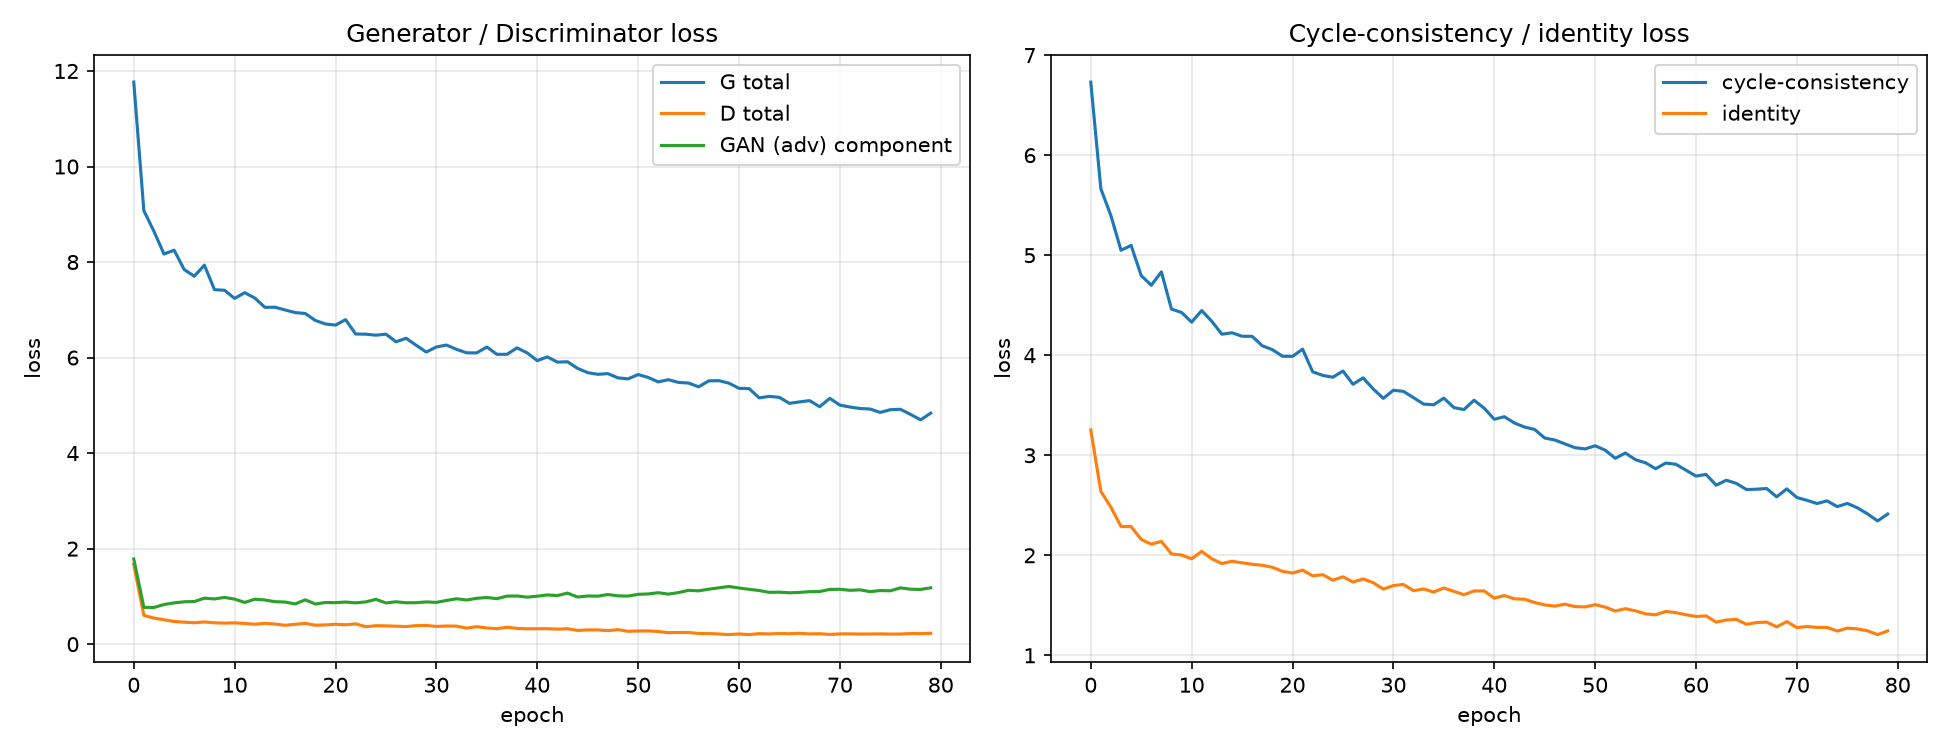

In [1]:
from IPython.display import Image
Image('../outputs/loss_curves.png')

## Run: `python generate.py`
Real captured output:

In [1]:
print(open('../outputs/console_generate.log').read())

pred_A2B (monet->photo): 300 images in 9.0s (33.36 img/s)
pred_B2A (photo->monet): 7038 images in 34.5s (204.13 img/s)  <-- Kaggle submission direction
Wrote ../outputs\images.zip -- upload THIS file to the Kaggle competition.
Wrote ..\submission.csv (manifest of what's in images.zip)


## Run: `python evaluate_local.py`
Real captured output:

In [1]:
print(open('../outputs/console_eval.log').read())

 10%|9         | 22.2M/233M [00:00<00:01, 117MB/s]
 14%|#4        | 33.5M/233M [00:00<00:01, 117MB/s]
 19%|#9        | 44.9M/233M [00:00<00:01, 118MB/s]
 24%|##4       | 56.2M/233M [00:00<00:01, 118MB/s]
 29%|##9       | 67.6M/233M [00:00<00:01, 118MB/s]
 34%|###3      | 79.0M/233M [00:00<00:01, 118MB/s]
 39%|###8      | 90.4M/233M [00:00<00:01, 118MB/s]
 44%|####3     | 102M/233M [00:00<00:01, 118MB/s] 
 49%|####8     | 113M/233M [00:01<00:01, 118MB/s]
 53%|#####3    | 124M/233M [00:01<00:00, 118MB/s]
 58%|#####8    | 136M/233M [00:01<00:00, 119MB/s]
 63%|######3   | 147M/233M [00:01<00:00, 118MB/s]
 68%|######8   | 159M/233M [00:01<00:00, 118MB/s]
 73%|#######2  | 170M/233M [00:01<00:00, 119MB/s]
 78%|#######7  | 182M/233M [00:01<00:00, 118MB/s]
 83%|########2 | 193M/233M [00:01<00:00, 119MB/s]
 88%|########7 | 204M/233M [00:01<00:00, 118MB/s]
 93%|#########2| 216M/233M [00:01<00:00, 118MB/s]
 97%|#########7| 227M/233M [00:02<00:00, 118MB/s]
100%|##########| 233M/233M [00:02<00:00, 1

### full_metrics_report.json

In [1]:
import json
print(json.dumps(json.load(open('../outputs/full_metrics_report.json')), indent=2))

{
  "fid_photo_to_monet_B2A": 123.70142207719508,
  "fid_monet_to_photo_A2B": 120.72189135388714,
  "kid_photo_to_monet_B2A": 0.02674577198922634,
  "kid_photo_to_monet_B2A_std": 0.0028846028726547956,
  "kid_monet_to_photo_A2B": 0.040115561336278915,
  "kid_monet_to_photo_A2B_std": 0.003394568106159568,
  "precision_photo_to_monet_B2A": 0.32666666666666666,
  "recall_photo_to_monet_B2A": 0.57,
  "precision_monet_to_photo_A2B": 0.6133333333333333,
  "recall_monet_to_photo_A2B": 0.20666666666666667,
  "cycle_A_monet_photo_monet": {
    "cycle_l1_mean": 0.10935583457350731,
    "lpips_mean": 0.40471330359578134,
    "content_cosine_sim_mean": 0.8733191460371017,
    "n_images": 100
  },
  "cycle_B_photo_monet_photo": {
    "cycle_l1_mean": 0.12576062157750129,
    "lpips_mean": 0.3373443901538849,
    "content_cosine_sim_mean": 0.7753308209776878,
    "n_images": 100
  },
  "device": "cuda",
  "total_parameter_count": 28285832,
  "epochs_trained": 80,
  "final_loss_G": 4.835439472198487,

### full_metrics_report.csv

In [1]:
print(open('../outputs/full_metrics_report.csv').read())

metric,value
fid_photo_to_monet_B2A,123.70142207719508
fid_monet_to_photo_A2B,120.72189135388714
kid_photo_to_monet_B2A,0.02674577198922634
kid_photo_to_monet_B2A_std,0.0028846028726547956
kid_monet_to_photo_A2B,0.040115561336278915
kid_monet_to_photo_A2B_std,0.003394568106159568
precision_photo_to_monet_B2A,0.32666666666666666
recall_photo_to_monet_B2A,0.57
precision_monet_to_photo_A2B,0.6133333333333333
recall_monet_to_photo_A2B,0.20666666666666667
cycle_A_monet_photo_monet.cycle_l1_mean,0.10935583457350731
cycle_A_monet_photo_monet.lpips_mean,0.40471330359578134
cycle_A_monet_photo_monet.content_cosine_sim_mean,0.8733191460371017
cycle_A_monet_photo_monet.n_images,100
cycle_B_photo_monet_photo.cycle_l1_mean,0.12576062157750129
cycle_B_photo_monet_photo.lpips_mean,0.3373443901538849
cycle_B_photo_monet_photo.content_cosine_sim_mean,0.7753308209776878
cycle_B_photo_monet_photo.n_images,100
device,cuda
total_parameter_count,28285832
epochs_trained,80
final_loss_G,4.835439472198487
fina